In [1]:
from google.colab import files
uploaded = files.upload()

Saving xy_data.csv to xy_data.csv


In [2]:
import pandas as pd

df = pd.read_csv('xy_data.csv')
print(df.shape)
df.head()


(1500, 2)


,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340


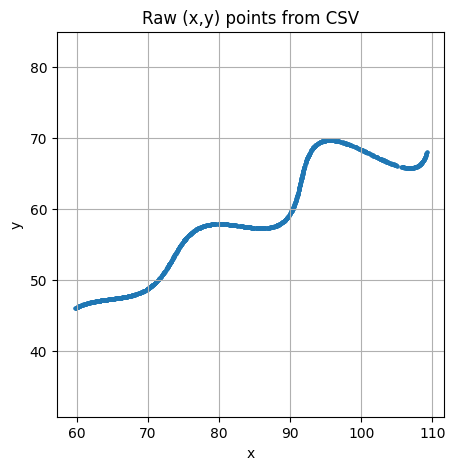

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(df['x'], df['y'], s=4)
plt.title('Raw (x,y) points from CSV')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal'); plt.grid(True)
plt.show()


In [4]:
import numpy as np

N = len(df)
t = np.linspace(6, 60, N)

x = df['x'].to_numpy()
y = df['y'].to_numpy()

print("Number of points:", N)
print("t range:", t[0], "to", t[-1])


Number of points: 1500
t range: 6.0 to 60.0


In [5]:
def fit_u_for_theta(theta_deg, x, y, t):
    """Compute the best X and MSE for a given theta (degrees)."""
    th = np.deg2rad(theta_deg)
    c, s = np.cos(th), np.sin(th)
    if abs(c) < 1e-10:
        return np.inf, None, None
    u_noX = x*c + y*s - 42*s
    X_hat = (u_noX.sum() - t.sum()) / (c * len(t))
    u = u_noX - X_hat*c
    mse_u = np.mean((u - t)**2)
    return mse_u, X_hat, u

thetas = np.linspace(0.01, 49.99, 1000)
best = None

for th in thetas:
    mse_u, Xh, u = fit_u_for_theta(th, x, y, t)
    if np.isfinite(mse_u) and (best is None or mse_u < best[0]):
        best = (mse_u, th, Xh, u)

mse_u_best, theta_deg, X_hat, u_best = best
print("Best theta (deg):", theta_deg)
print("Best X:", X_hat)
print("MSE_u:", mse_u_best)


Best theta (deg): 0.01
Best X: 50.716769472999744
MSE_u: 452.9081595069172


In [6]:
import numpy as np

th = np.deg2rad(theta_deg)
c, s = np.cos(th), np.sin(th)

u = (x - X_hat) * c + (y - 42) * s
v = -(x - X_hat) * s + (y - 42) * c

sig = np.sin(0.3 * t)
mask = np.abs(sig) > 1e-6

y_reg = np.log(np.abs(v[mask])) - np.log(np.abs(sig[mask]))
A = np.vstack([t[mask], np.ones(mask.sum())]).T
M_hat, c0 = np.linalg.lstsq(A, y_reg, rcond=None)[0]

print("Estimated M:", M_hat)
print("Intercept c0:", c0)


Estimated M: -0.005513209428831841
Intercept c0: 3.5005145253582324


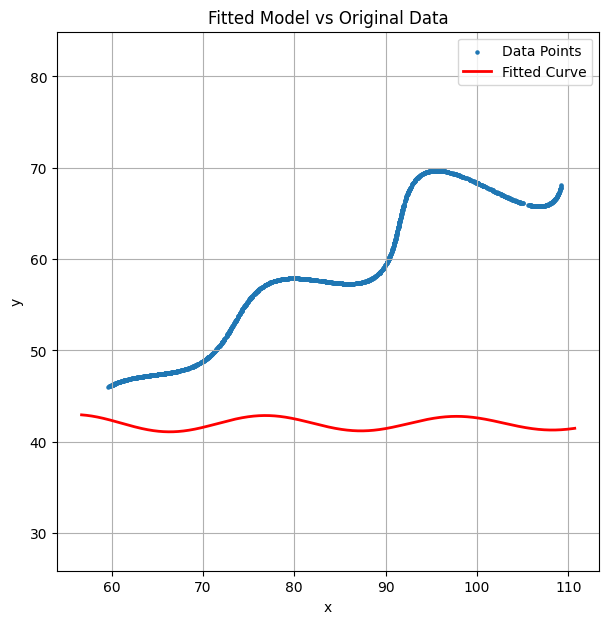

In [7]:
x_pred = t*np.cos(th) - np.exp(M_hat*np.abs(t))*np.sin(0.3*t)*np.sin(th) + X_hat
y_pred = 42 + t*np.sin(th) + np.exp(M_hat*np.abs(t))*np.sin(0.3*t)*np.cos(th)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(x, y, s=5, label="Data Points")
plt.plot(x_pred, y_pred, 'r', lw=2, label="Fitted Curve")
plt.legend()
plt.axis("equal")
plt.title("Fitted Model vs Original Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


In [8]:
from scipy.optimize import minimize

def total_error(params, x, y, t):
    theta_deg, M, X = params
    th = np.deg2rad(theta_deg)
    c, s = np.cos(th), np.sin(th)
    x_pred = t*c - np.exp(M*np.abs(t))*np.sin(0.3*t)*s + X
    y_pred = 42 + t*s + np.exp(M*np.abs(t))*np.sin(0.3*t)*c
    return np.mean((x - x_pred)**2 + (y - y_pred)**2)

initial_guess = [theta_deg, M_hat, X_hat]

bounds = [(0, 50), (-0.05, 0.05), (0, 100)]

res = minimize(total_error, initial_guess, args=(x, y, t), bounds=bounds)
theta_opt, M_opt, X_opt = res.x
print("Refined θ (deg):", theta_opt)
print("Refined M:", M_opt)
print("Refined X:", X_opt)
print("Final error:", res.fun)


Refined θ (deg): 29.582835112838104
Refined M: -0.05
Refined X: 55.01361377363524
Final error: 514.4579282422708


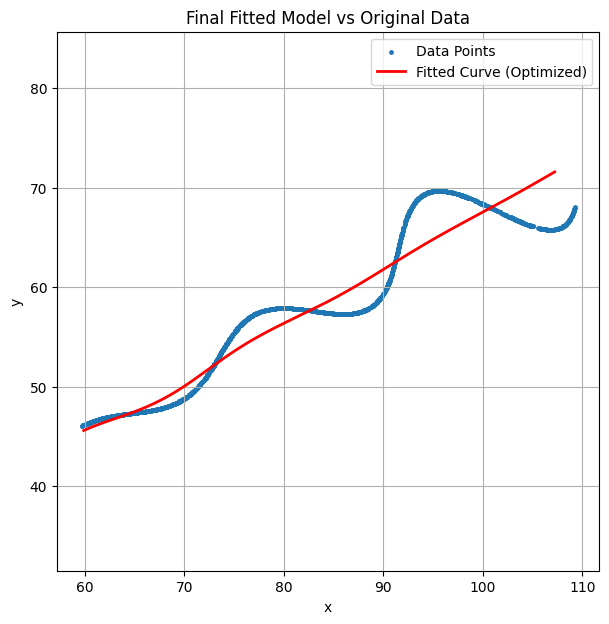

In [10]:

theta_deg = 29.582835112838104
M_hat = -0.05
X_hat = 55.01361377363524
th = np.deg2rad(theta_deg)
c, s = np.cos(th), np.sin(th)

x_pred = t * c - np.exp(M_hat * np.abs(t)) * np.sin(0.3 * t) * s + X_hat
y_pred = 42 + t * s + np.exp(M_hat * np.abs(t)) * np.sin(0.3 * t) * c


import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(x, y, s=6, label="Data Points")
plt.plot(x_pred, y_pred, 'r', lw=2, label="Fitted Curve (Optimized)")
plt.legend()
plt.axis("equal")
plt.title("Final Fitted Model vs Original Data")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(True)
plt.show()


In [11]:

L1 = np.mean(np.abs(x - x_pred) + np.abs(y - y_pred))
print("L1 distance between predicted and actual curve:", L1)


L1 distance between predicted and actual curve: 25.401462411398555
